
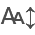

/mnt/DATA/home/ethung/spatial_seq/.venv/lib/python3.12/site-packages/scvi/__init__.py:31: DeprecationWarning: scvi is deprecated, please uninstall scvi via `pip uninstall scvi` and install the new scvi-tools package at github.com/YosefLab/scvi-tools
  warnings.warn(deprecation_msg, DeprecationWarning)
/mnt/DATA/home/ethung/spatial_seq/.venv/lib/python3.12/site-packages/phenograph/cluster.py:13: DeprecationWarning: Please import `spmatrix` from the `scipy.sparse` namespace; the `scipy.sparse.base` namespace is deprecated and will be removed in SciPy 2.0.0.
  from scipy.sparse.base import spmatrix


In [1]:
%load_ext jupyter_black

# base
import os
from pathlib import Path
import warnings
import logging

logging.basicConfig(level="WARNING")
warnings.simplefilter("ignore", FutureWarning)
warnings.simplefilter("ignore", UserWarning)
warnings.simplefilter("ignore", RuntimeWarning)

# data manipulation
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import itables

itables.init_notebook_mode(all_interactive=True)

warnings.simplefilter("ignore", pd.errors.DtypeWarning)
mlogger = logging.getLogger("matplotlib")
mlogger.setLevel(logging.WARNING)

# single cell
import scanpy as sc
import squidpy as sq
import spatialdata as sd
import spatialdata_plot as sdp
import spatialdata_io

# custom
from single_cell.R import *
from single_cell.preprocess import *
from single_cell.plot import *
from single_cell.analysis import *
from spatial_seq.plot import *
from utils import *

converter = get_converter()
%load_ext rpy2.ipython
# analysis & device specific
%matplotlib inline
CORES = 10
DATADIR = Path("../../../data")
REFDIR = Path("../../../references")

In [2]:
# LOAD PROCESSED
sdata = sd.read_zarr(DATADIR / "processed" / "spatial" / "raws" / "COMBINED")
samples = list(sdata["square_008um"].obs["Identifier"].unique())

In [ ]:
samples = os.listdir(DATADIR / "spaceranger" / "LM13969")[1:]
print(samples)
adatas = [
    read_visium_hd_segmented(
        DATADIR / "spaceranger" / "LM13969" / sample / "outs", sample_id=sample
    )
    for sample in tqdm(samples)
]

['LFD-CTR-male-670-VAT', 'HFD-cKO-male-666-VAT', 'LFD-cKO-male-780-VAT']


  0%|          | 0/3 [00:00<?, ?it/s]

100%|██████████| 3/3 [00:10<00:00,  3.65s/it]


In [96]:
adatas[2].uns["spatial"][samples[2]]["scalefactors"]

{'microns_per_pixel': 0.13688942605391358,
 'tissue_lowres_scalef': 0.008724734,
 'fiducial_diameter_fullres': 2410.704825879175,
 'tissue_hires_scalef': 0.08724735,
 'regist_target_img_scalef': 0.08724735,
 'spot_diameter_fullres': np.float64(97.81148325575589)}

Cells removed by gene/count filters: 28827 (49.50%)
Cells with >15% mito genes: 0 (0.00%)
Remaining bins: 29412

Saving normalized counts in layer 'normalized'.
Cells removed by gene/count filters: 43852 (72.23%)
Cells with >15% mito genes: 0 (0.00%)
Remaining bins: 16856

Saving normalized counts in layer 'normalized'.
Cells removed by gene/count filters: 59954 (90.86%)
Cells with >15% mito genes: 0 (0.00%)
Remaining bins: 6031

Saving normalized counts in layer 'normalized'.


AnnData object with n_obs × n_vars = 52299 × 10338
    obs: 'location_id', 'region', 'n_genes', 'n_counts', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'pct_counts_mito', 'Identifier'
    obsm: 'spatial'
    layers: 'counts', 'normalized'

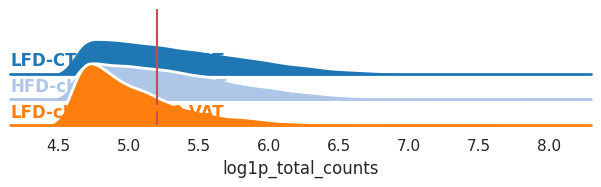

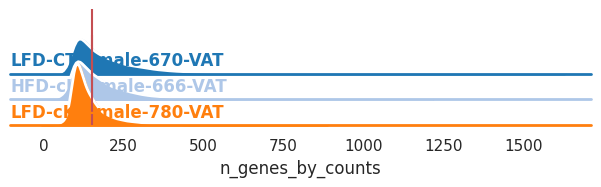

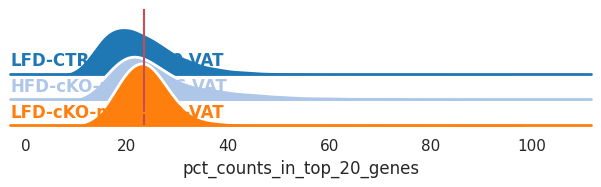

In [39]:
runFilters = True
processed = []

# QC Thresholds
filters = {"GenesPerCell": 0, "ReadsPerCell": 100, "CellsPerGene": 10, "Mito%": 15}

for n, ad in enumerate(adatas):
    adata = ad.copy()

    # Standard QC Filters
    Filter_QC(
        adata,
        GenePerCell=filters["GenesPerCell"],
        CountPerCell=filters["ReadsPerCell"],
        CellPerGene=filters["CellsPerGene"],
        verbose=True,
    )
    Filter_GeneGroup(
        adata,
        key="mito",
        marker="mt",
        verbose=True,
        perc_threshold=filters["Mito%"],
    )

    print(f"Remaining bins: {adata.shape[0]}\n")
    adata.obs["Identifier"] = samples[n]
    adata.layers["counts"] = adata.X.copy()
    Normalize(adata)
    adata.X = adata.layers["counts"].copy()

    processed.append(adata)

adata_FULL = sc.concat(processed)

groupby = "Identifier"
check_QCPlot(adata_FULL.obs, "log1p_total_counts", groupby)
check_QCPlot(adata_FULL.obs, "n_genes_by_counts", groupby)
check_QCPlot(adata_FULL.obs, "pct_counts_in_top_20_genes", groupby)
adata_FULL

In [ ]:
batch_column = "Identifier"
Normalize(adata_FULL)

Saving normalized counts in layer 'normalized'.


AnnData object with n_obs × n_vars = 52299 × 10338
    obs: 'location_id', 'region', 'n_genes', 'n_counts', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'pct_counts_mito', 'Identifier'
    uns: 'methods', 'log1p'
    obsm: 'spatial'
    layers: 'counts', 'normalized'

In [42]:
for adata in processed:
    sq.gr.spatial_neighbors(adata)
    sq.gr.spatial_autocorr(adata, mode="moran", genes=adata.var_names)

In [89]:
pd.concat(
    [
        adata.uns["moranI"].reset_index().reset_index().iloc[:, :2]
        for adata in processed
    ],
    axis=1,
)

Loading ITables v2.4.4 from the init_notebook_mode cell... (need help?)


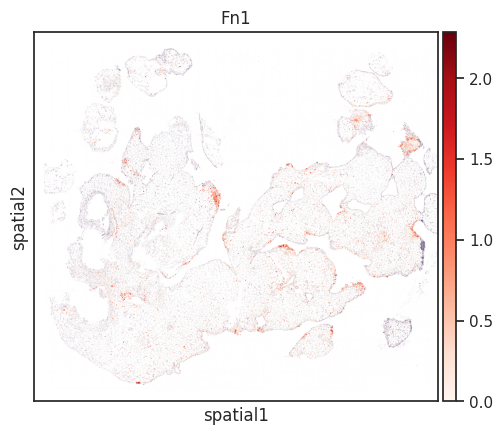

In [81]:
sc.pl.spatial(processed[0], color=["Fn1"], cmap="Reds", layer="normalized")

In [37]:
adata.uns["moranI"].head(50)

Loading ITables v2.4.4 from the init_notebook_mode cell... (need help?)
